In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import os

os.chdir(r'C:/Users/aruna/Desktop/Work/MLDAY1')

df=pd.read_csv('Titanic-Cleaned.csv')
X=df.drop(columns=['Survived'])
y=df['Survived']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)



In [2]:
# single split result — what we've been doing
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

print(f"Single split accuracy: {accuracy_score(y_test,model.predict(X_test)):.4f}")

cv_scores= cross_val_score(model,X,y,cv=5,scoring='accuracy')
print(f"CV scores:{cv_scores}")
print(f"CV mean: {cv_scores.mean():.4f}")
print(f"CV std: {cv_scores.std():.4f}")



Single split accuracy: 0.8212
CV scores:[0.78212291 0.80337079 0.86516854 0.78089888 0.8258427 ]
CV mean: 0.8115
CV std: 0.0315


In [5]:
param_grid= {
    'n_estimators' : [50,100,200],
    'max_depth' :[3,5,7,None],
    'min_samples_split' : [2,5,10]
}

grid_search= GridSearchCV(RandomForestClassifier(random_state=42),param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid_search.fit(X_train,y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# evaluate best model on test set
best_model = grid_search.best_estimator_
print(f"Test accuracy: {accuracy_score(y_test, best_model.predict(X_test)):.4f}")

Best params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
Best CV score: 0.8370
Test accuracy: 0.8045


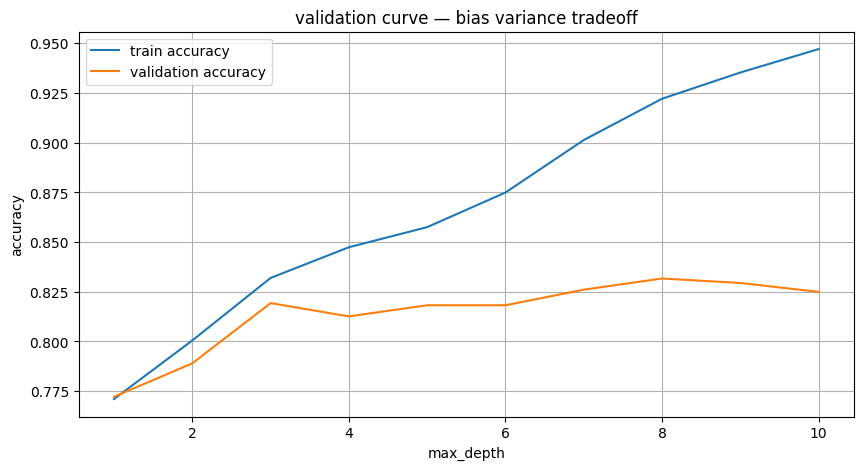

In [6]:
from sklearn.model_selection import validation_curve

depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X, y,
    param_name='max_depth',
    param_range=depths,
    cv=5,
    scoring='accuracy')

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(depths, train_mean, label='train accuracy')
plt.plot(depths, val_mean, label='validation accuracy')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.title('validation curve — bias variance tradeoff')
plt.legend()
plt.grid(True)
plt.show()

C= 0.001 → CV accuracy: 0.6802
C=  0.01 → CV accuracy: 0.7307
C=   0.1 → CV accuracy: 0.7980
C=     1 → CV accuracy: 0.7957
C=    10 → CV accuracy: 0.7924
C=   100 → CV accuracy: 0.7924


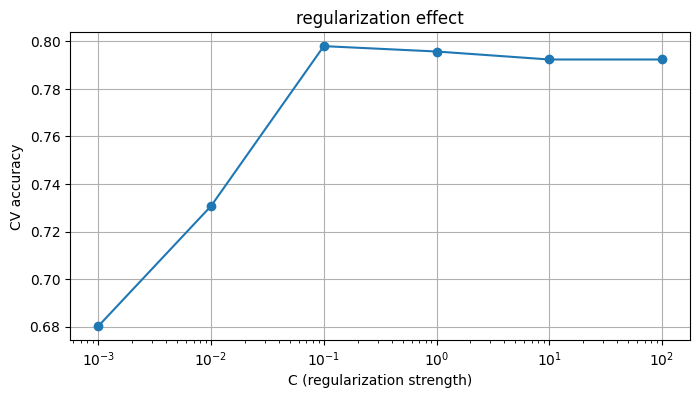

In [7]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
cv_scores = []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000)
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"C={C:6} → CV accuracy: {scores.mean():.4f}")

plt.figure(figsize=(8, 4))
plt.semilogx(C_values, cv_scores, marker='o')
plt.xlabel('C (regularization strength)')
plt.ylabel('CV accuracy')
plt.title('regularization effect')
plt.grid(True)
plt.show()